# CK Whole-Video Keyframe Distribution Summary

Source metadata: `N:\Experimental_Data\yujunchen\projects\AI_ratings\ck_whole_video_keyframes\summary.json`  
Frame output root: `N:\Experimental_Data\yujunchen\projects\AI_ratings\ck_whole_video_keyframes`

## Headline Results

| Metric | Value |
|---|---:|
| Videos processed | 2,196 |
| Successful videos | 2,196 |
| Failed videos | 0 |
| Total saved frame images | 12,308 |
| Mean saved frames/video | 5.60 |
| Median saved frames/video | 3.50 |
| Min saved frames/video | 2 |
| Max saved frames/video | 19 |
| Mean video duration | 6.61 s |
| Median video duration | 4.50 s |

The extractor used the CK whole-video rule: approximately 1 frame/second, clamped to 3-20 requested frames, over the full video window. The observed extracted/saved frame count can be lower: the minimum saved count is 2 because OpenCV usually cannot read the exact final timestamp, so nearly every video saved one fewer frame than requested.

## Notes

- `requested_frames` is the CK whole-video target frame budget before frame read failures; it can be higher than the number of saved files.
- `saved_frames` is the number of JPEGs actually written to each video subfolder; this is the extracted-frame count used in the plots.
- `frame_shortfall = requested_frames - saved_frames`; this is usually 1 due to the unreadable exact final timestamp.
- `effective_sampling` is `uniform` for clips at or below the 10-second threshold and `key_moments` above it when `sampling='auto'`.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

summary_path = Path(r'N:\Experimental_Data\yujunchen\projects\AI_ratings\ck_whole_video_keyframes\summary.json')
summary = json.loads(summary_path.read_text(encoding='utf-8'))
df = pd.DataFrame([{k: v for k, v in row.items() if k != 'frames'} for row in summary['results']])
df['duration_sec'] = df['duration_ms'] / 1000.0
df['frame_shortfall'] = df['requested_frames'] - df['saved_frames']
df.head()

  video_id video_name                                                                           video_path                        out_dir  duration_ms     fps  source_frame_count  requested_frames  saved_frames sampling effective_sampling  key_moment_threshold_sec frame_format status  duration_sec  frame_shortfall  saved_frame_rate_per_sec duration_bin_sec
0     0001   0001.mp4  N:\Experimental_Data\yujunchen\projects\data\original_ckvideo_data\ckvideo\0001.mp4  ck_whole_video_keyframes\0001       3760.0  12.500                  47                 4             3     auto            uniform                      10.0          jpg     ok          3.76                1                  0.797872              3-5
1     0002   0002.mp4  N:\Experimental_Data\yujunchen\projects\data\original_ckvideo_data\ckvideo\0002.mp4  ck_whole_video_keyframes\0002       2560.0  25.000                  64                 3             2     auto            uniform                      10.0          jpg     

## Descriptive Statistics


In [2]:
df[['duration_sec', 'source_frame_count', 'requested_frames', 'saved_frames', 'frame_shortfall']].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).round(3)


,duration_sec,source_frame_count,requested_frames,saved_frames,frame_shortfall
count,2196.000,2196.000,2196.000,2196.000,2196.00
mean,6.612,125.086,6.605,5.605,1.00
std,6.859,179.743,4.630,4.630,0.03
min,0.152,4.000,3.000,2.000,0.00
1%,0.600,8.950,3.000,2.000,1.00
5%,1.050,14.000,3.000,2.000,1.00
25%,2.400,30.750,3.000,2.000,1.00
50%,4.505,62.000,4.500,3.500,1.00
75%,9.100,149.250,9.000,8.000,1.00
95%,15.120,378.000,15.000,14.000,1.00


## Extracted/Saved Frames Per Video

This is the actual number of frame images written to each video folder. The observed minimum is 2.


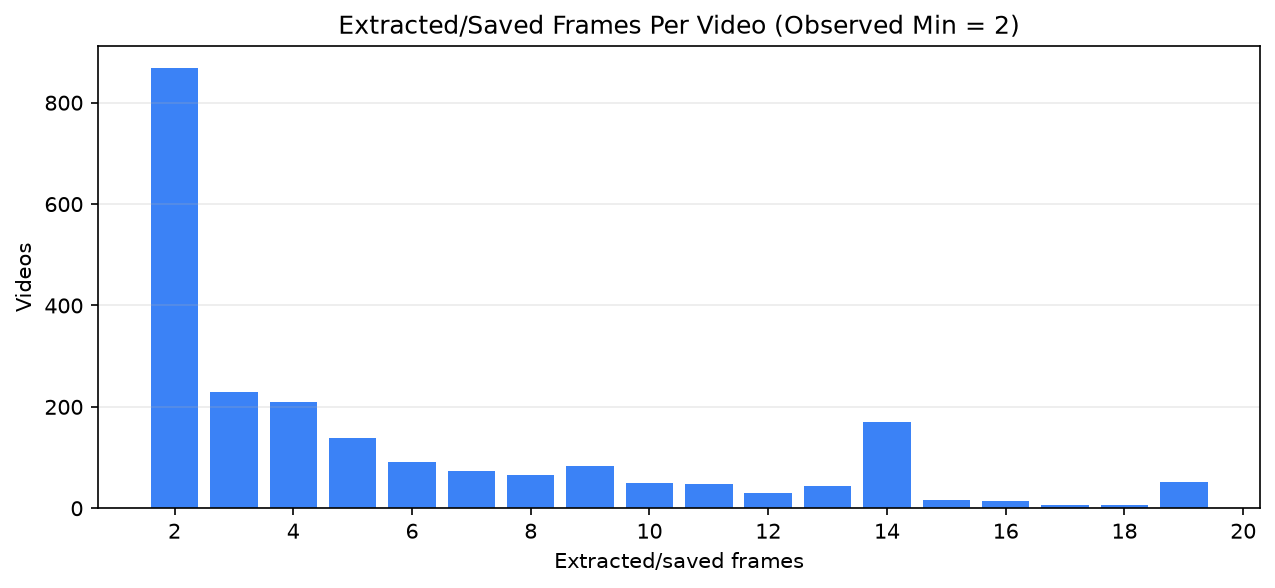

extracted_saved_frames,n_videos
2,868
3,230
4,210
5,139
6,91
7,73
8,66
9,83
10,49
11,47


In [3]:
saved_counts = df['saved_frames'].value_counts().sort_index().rename_axis('extracted_saved_frames').reset_index(name='n_videos')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(saved_counts['extracted_saved_frames'], saved_counts['n_videos'], color='#3B82F6')
ax.set_title('Extracted/Saved Frames Per Video (Observed Min = 2)')
ax.set_xlabel('Extracted/saved frames')
ax.set_ylabel('Videos')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.25)
plt.show()
saved_counts


## CK Target Frames Before Read Failures

This is the CK sampling target/requested count before OpenCV frame-read failures. It is not the same as the number of files saved in each video folder.


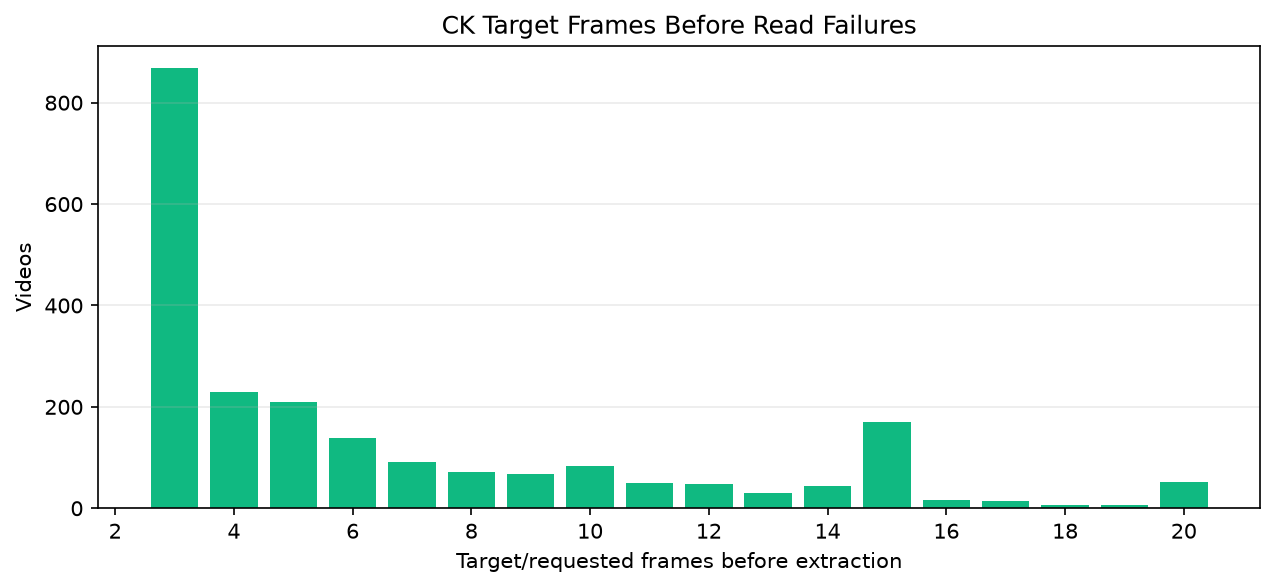

requested_frames,n_videos
3,868
4,230
5,210
6,139
7,91
8,72
9,67
10,83
11,49
12,47


In [4]:
requested_counts = df['requested_frames'].value_counts().sort_index().rename_axis('requested_frames').reset_index(name='n_videos')
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(requested_counts['requested_frames'], requested_counts['n_videos'], color='#10B981')
ax.set_title('CK Target Frames Before Read Failures')
ax.set_xlabel('Target/requested frames before extraction')
ax.set_ylabel('Videos')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.25)
plt.show()
requested_counts


## Duration Distribution (1-Second Bins)


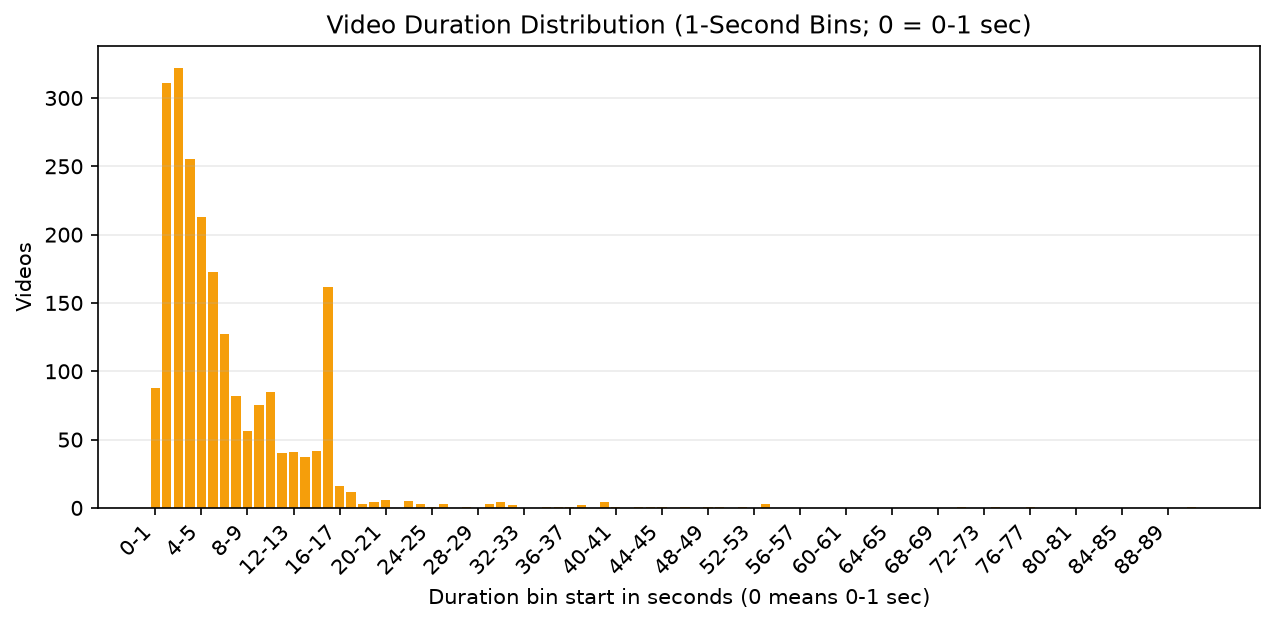

duration_bin_sec,duration_bin_start_sec,n_videos
0-1,0,88
1-2,1,311
2-3,2,322
3-4,3,255
4-5,4,213
5-6,5,173
6-7,6,127
7-8,7,82
8-9,8,56
9-10,9,75


In [5]:
# 1-second duration bins: [0,1), [1,2), ...
import math

max_bin = int(math.ceil(df['duration_sec'].max()))
duration_counts_1s = (
    df.assign(duration_bin_start_sec=df['duration_sec'].apply(lambda x: int(math.floor(x))))
    ['duration_bin_start_sec']
    .value_counts()
    .sort_index()
    .reindex(range(0, max_bin + 1), fill_value=0)
    .rename_axis('duration_bin_start_sec')
    .reset_index(name='n_videos')
)
duration_counts_1s['duration_bin_sec'] = duration_counts_1s['duration_bin_start_sec'].map(lambda x: f'{x}-{x+1}')
duration_counts_1s = duration_counts_1s[['duration_bin_sec', 'duration_bin_start_sec', 'n_videos']]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(duration_counts_1s['duration_bin_start_sec'], duration_counts_1s['n_videos'], color='#F59E0B')
ax.set_title('Video Duration Distribution (1-Second Bins; 0 = 0-1 sec)')
ax.set_xlabel('Duration bin start in seconds (0 means 0-1 sec)')
ax.set_ylabel('Videos')
ax.set_xticks(range(0, max_bin + 1, 5))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.25)
plt.show()
duration_counts_1s


## Effective Sampling Mode


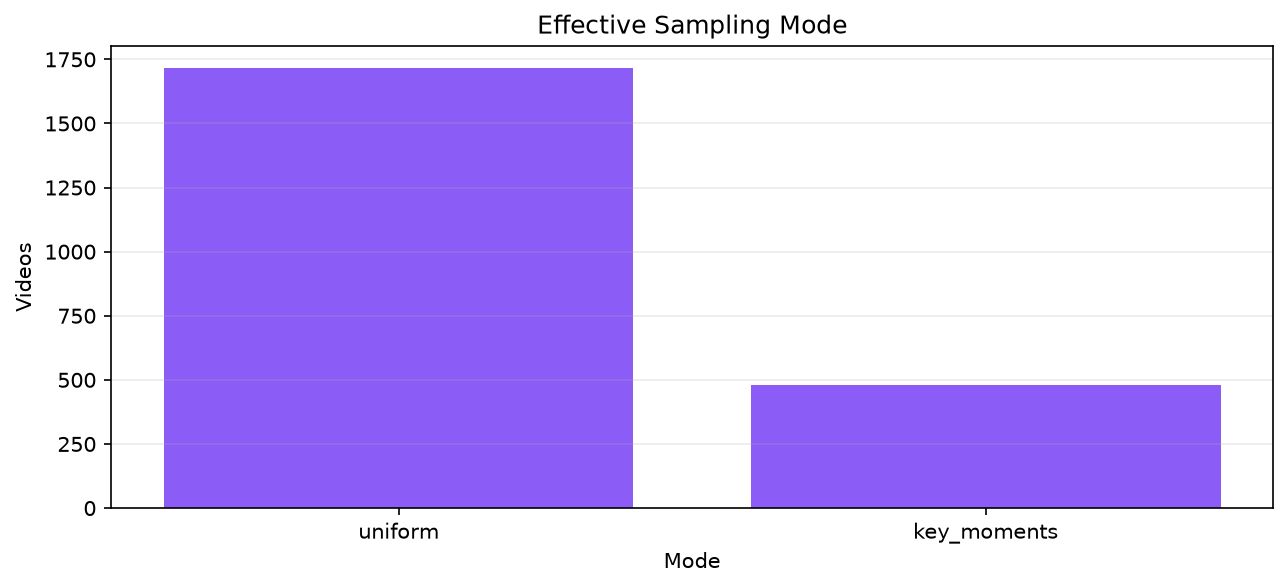

effective_sampling,n_videos
uniform,1716
key_moments,480


In [6]:
sampling_counts = df['effective_sampling'].value_counts().rename_axis('effective_sampling').reset_index(name='n_videos')
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(sampling_counts['effective_sampling'], sampling_counts['n_videos'], color='#8B5CF6')
ax.set_title('Effective Sampling Mode')
ax.set_xlabel('Mode')
ax.set_ylabel('Videos')
ax.grid(axis='y', alpha=0.25)
plt.show()
sampling_counts


## Frame Shortfall


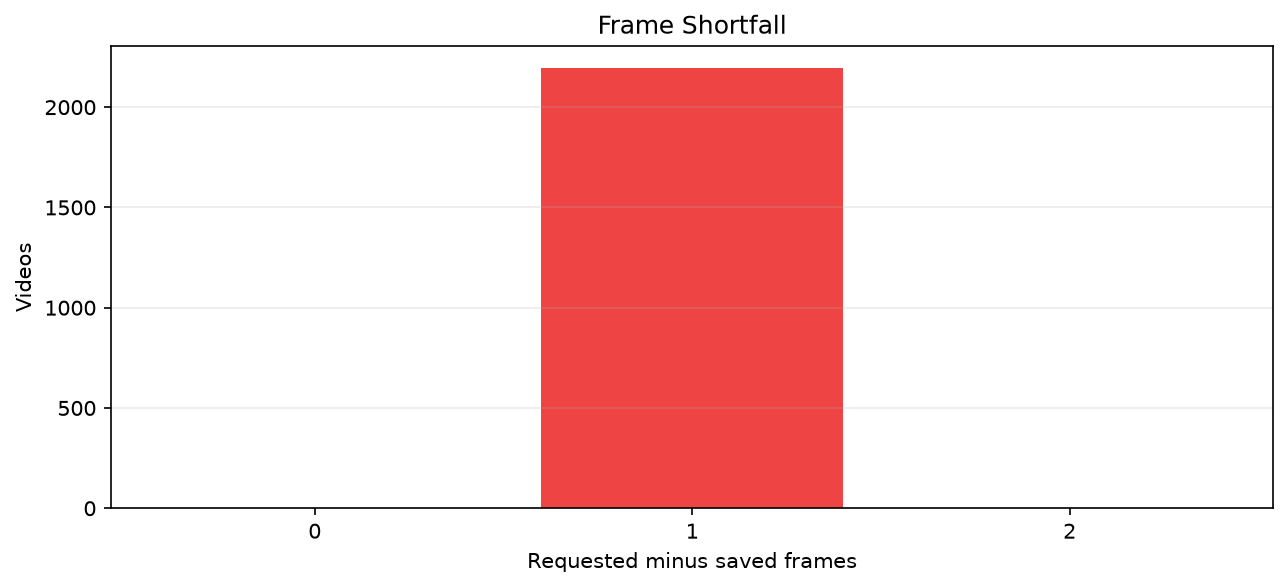

requested_minus_saved,n_videos
0,1
1,2194
2,1


In [7]:
shortfall_counts = df['frame_shortfall'].value_counts().sort_index().rename_axis('requested_minus_saved').reset_index(name='n_videos')
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(shortfall_counts['requested_minus_saved'], shortfall_counts['n_videos'], color='#EF4444')
ax.set_title('Frame Shortfall')
ax.set_xlabel('Requested minus saved frames')
ax.set_ylabel('Videos')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis='y', alpha=0.25)
plt.show()
shortfall_counts


## Extracted Frames and Video Length by Video

Extracted/saved frames are plotted against the left y-axis, with integer ticks including 2 and 3. Video length is overlaid as an orange line against the right y-axis in seconds.


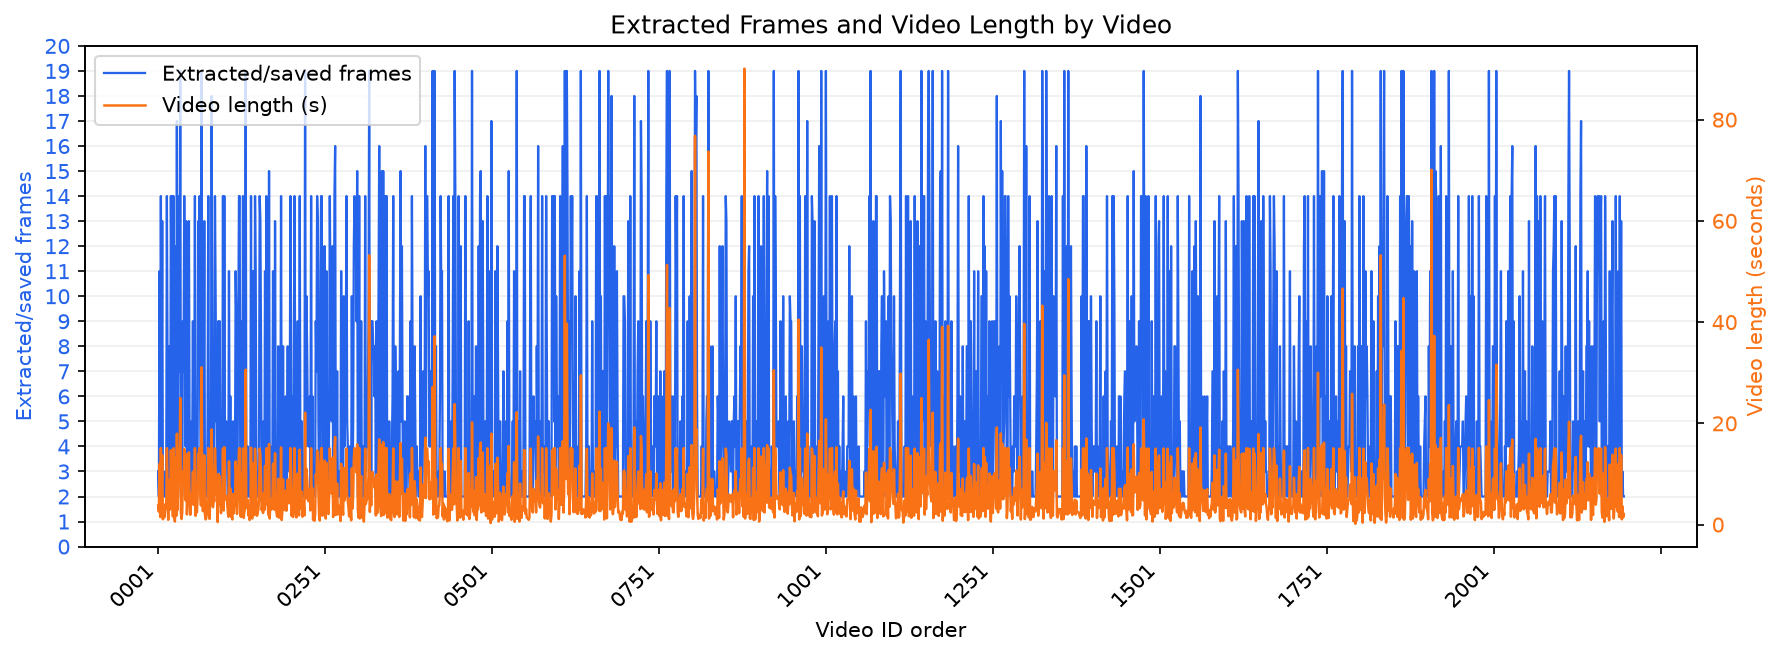

In [ ]:
plot_df = df.sort_values([pd.to_numeric(df['video_id'], errors='coerce'), 'video_id']).reset_index(drop=True)
x = range(len(plot_df))
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(x, plot_df['saved_frames'], color='#2563EB', linewidth=1.1, label='Extracted/saved frames')
ax1.set_ylabel('Extracted/saved frames', color='#2563EB')
ax1.set_ylim(0, 20)
ax1.set_yticks(range(0, 21, 1))
ax1.tick_params(axis='y', labelcolor='#2563EB')
ax1.grid(axis='y', alpha=0.2)

ax2 = ax1.twinx()
ax2.plot(x, plot_df['duration_sec'], color='#F97316', linewidth=1.2, label='Video length (s)')
ax2.set_ylabel('Video length (seconds)', color='#F97316')
ax2.tick_params(axis='y', labelcolor='#F97316')

tick_positions = [i for i in [0, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, len(plot_df) - 1] if 0 <= i < len(plot_df)]
ax1.set_xticks(tick_positions)
ax1.set_xticklabels(plot_df.loc[tick_positions, 'video_id'].astype(str), rotation=45, ha='right')
ax1.set_xlabel('Video ID order')
ax1.set_title('Extracted Frames and Video Length by Video')
ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

lines = ax1.get_lines() + ax2.get_lines()
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')
plt.show()


## Duration vs Extracted/Saved Frames


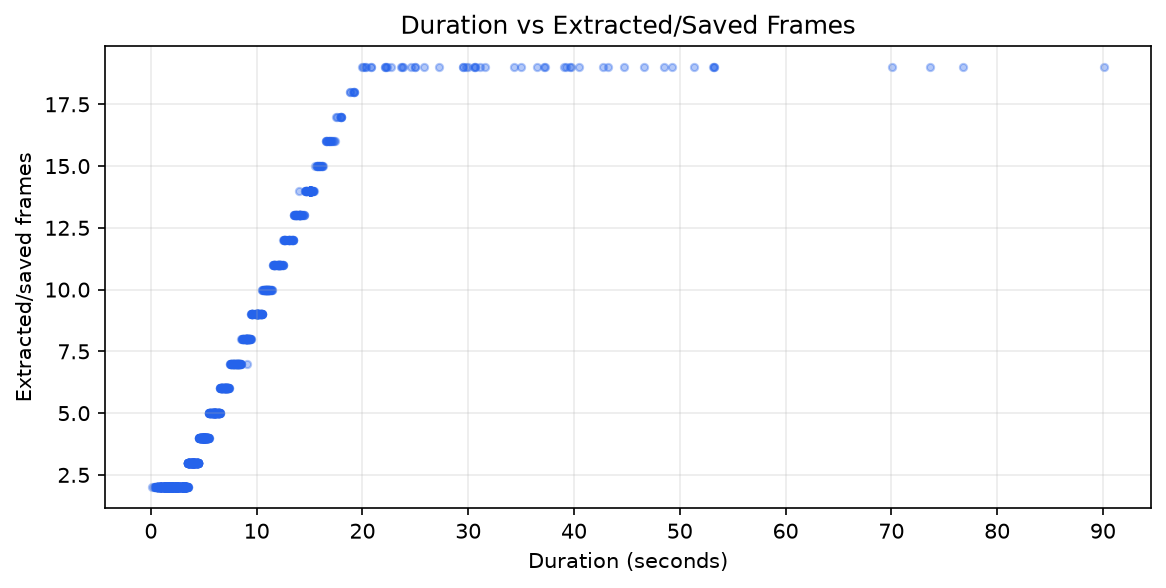

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(df['duration_sec'], df['saved_frames'], s=12, alpha=0.35, color='#2563EB')
ax.set_title('Duration vs Extracted/Saved Frames')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Extracted/saved frames')
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(alpha=0.25)
plt.show()


## Longest Capped Examples

These examples reached the 20-requested-frame cap.


In [9]:
df[df['requested_frames'] == 20].sort_values('duration_sec', ascending=False)[['video_id', 'duration_sec', 'source_frame_count', 'requested_frames', 'saved_frames', 'effective_sampling']].head(10)


video_id,duration_sec,source_frame_count,requested_frames,saved_frames,effective_sampling
0879,90.07,2702,20,19,key_moments
0805,76.80,768,20,19,key_moments
0825,73.70,737,20,19,key_moments
1908,70.10,701,20,19,key_moments
0317,53.20,532,20,19,key_moments
1832,53.20,266,20,19,key_moments
0610,53.12,1244,20,19,key_moments
0763,51.30,513,20,19,key_moments
0735,49.30,1479,20,19,key_moments
1364,48.51,1617,20,19,key_moments
